## **Proyecto de Analisis: La Gran Prueba de Sabor**






**Una consultora** ha sido contratada para realizar un **análisis de mercado** y **proporcionar recomendaciones estratégicas** para la apertura de una cafetería en EE.UU.  

Se le solicitó llevar a cabo un estudio utilizando los datos de la encuesta [**"La Gran Prueba de Sabor"**](https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv), con el fin de extraer información sobre las preferencias de los consumidores y ayudar al grupo inversor a diseñar una estrategia informada para su incursión en el sector. Esta encuesta la realizó el famoso barista *James Hoffmann* en octubre de 2023, durante una transmisión en vivo con unas *4.000 personas* en Estados Unidos.

## **Fase 1: Configuración y Adquisición de Datos**

En esta etapa inicial, automatizamos la descarga del dataset 'The Great Coffee Taste Test' mediante peticiones HTTP para asegurar la reproducibilidad del análisis


In [2]:
import requests

url_coffee_survey = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv"
archivo_salida_coffee_survey = "coffee_survey.csv"

def descargarCSV(url, archivo_salida):
    print("Descargando archivo...")
    consulta = requests.get(url)
    contenido = consulta.content

    print("Guardando archivo...")
    # Abrir conexion en modo escritura
    with open(archivo_salida, "w", encoding="utf-8") as archivo:
        # Escribir el contenido de la consulta
        archivo.write(contenido.decode("utf-8"))

    print("¡Archivo descargado con éxito!")

descargarCSV(url_coffee_survey,archivo_salida_coffee_survey)

Descargando archivo...
Guardando archivo...
¡Archivo descargado con éxito!


## **Fase 2: Auditoria y Calidad de datos**

Realizamos una inspección técnica de la estructura del dataset

In [3]:
import pandas as pd

# Cargar el archivo en el DataFrame
encuesta = pd.read_csv('coffee_survey.csv')
# Exploracion
print("\nTipos de datos por columna (encuesta.dtypes):")
print(encuesta.dtypes)


Tipos de datos por columna (encuesta.dtypes):
submission_id                    object
age                              object
cups                             object
where_drink                      object
brew                             object
brew_other                       object
purchase                         object
purchase_other                   object
favorite                         object
favorite_specify                 object
additions                        object
additions_other                  object
dairy                            object
sweetener                        object
style                            object
strength                         object
roast_level                      object
caffeine                         object
expertise                       float64
coffee_a_bitterness             float64
coffee_a_acidity                float64
coffee_a_personal_preference    float64
coffee_a_notes                   object
coffee_b_bitterness             f

In [4]:
encuesta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   submission_id                 4042 non-null   object 
 1   age                           4011 non-null   object 
 2   cups                          3949 non-null   object 
 3   where_drink                   3972 non-null   object 
 4   brew                          3657 non-null   object 
 5   brew_other                    678 non-null    object 
 6   purchase                      710 non-null    object 
 7   purchase_other                31 non-null     object 
 8   favorite                      3980 non-null   object 
 9   favorite_specify              114 non-null    object 
 10  additions                     3959 non-null   object 
 11  additions_other               48 non-null     object 
 12  dairy                         1686 non-null   object 
 13  swe

El archivo coffee_survey.csv contiene una encuesta sobre hábitos de consumo de café.

Información que brinda de cada persona encuestada:

- Identificación y Demografía: submission_id, age, gender, education, employment, country.

- Hábitos de Consumo: cups (tazas diarias), where_drink (lugares de consumo), favorite (bebida favorita), w_milk (prefiere leche), w_sugar (prefiere azúcar), best_prep (método de preparación preferido), best_roast (tostado preferido).

- Información Adicional: money (gasto semanal), exp_coffee (experiencia con café).

¿Todos los encuestados respondieron a todas las preguntas?

- No. Al usar el método .info(), se observará que la mayoría de las columnas tienen un conteo de valores no nulos menor al número total de registros (4042). Esto significa que hay valores faltantes (NaN o null) en muchas columnas, ya que algunos encuestados eligieron no responder a ciertas preguntas.

## **Fase 3: Procesamiento y Normalizacion de Variables**

Dada la naturaleza de la encuesta, algunas columnas contienen múltiples respuestas separadas por comas. Desarrollamos una lógica de normalización para desglosar estas categorías y obtener conteos precisos de frecuencias

In [5]:
# Conteo individual por rango de edad

conteo_edad = encuesta['age'].value_counts()

print("Conteo de encuestados por rango de edad (columna 'age'):")
print(conteo_edad)

Conteo de encuestados por rango de edad (columna 'age'):
age
25-34 years old    1986
35-44 years old     960
18-24 years old     461
45-54 years old     302
55-64 years old     187
>65 years old        95
<18 years old        20
Name: count, dtype: int64


In [6]:
# Conteo individual por lugar de consumo

conteo_donde_toma = encuesta['where_drink'].str.split(', ').explode().value_counts()

print("\nConteo de encuestados por lugar de consumo (columna 'where_drink'):")
print(conteo_donde_toma)


Conteo de encuestados por lugar de consumo (columna 'where_drink'):
where_drink
At home          3644
At the office    1430
At a cafe        1170
On the go         705
None of these      36
Name: count, dtype: int64


In [8]:
# Version Normalizada

def procesar_columna(dataframe, columna):
    # Recibe un dataframe y una columna del mismo. Devuelve una serie de pandas que muestra un conteo segun el filtro aplicado.
    es_multiple = dataframe[columna].str.contains(', ', na=False).any()

    return (
        dataframe[columna].str.split(', ').explode().value_counts()
        if es_multiple
        else dataframe[columna].value_counts()
        )

conteo_edad = procesar_columna(encuesta, 'age')

print("Resultado para 'age' (Conteo Simple):")
print(conteo_edad)

Resultado para 'age' (Conteo Simple):
age
25-34 years old    1986
35-44 years old     960
18-24 years old     461
45-54 years old     302
55-64 years old     187
>65 years old        95
<18 years old        20
Name: count, dtype: int64


## **Fase 4: Análisis Exploratorio y Segmentación**

Segmentamos la muestra por rangos etarios y niveles educativos. Esto nos permite identificar que el nicho de mercado más relevante posee estudios universitarios y se encuentra en el rango de 25-44 años.

In [9]:
conteo_gender = procesar_columna(encuesta, 'gender')
conteo_cups = procesar_columna(encuesta, 'cups')

In [10]:
# Función para filtrar por valor sobre una columna

def filtrar_columna_valor(dataframe, columna, valor):
    # Recibe un DataFrame, el nombre de una columna y un valor específico. Devuelve el dataframe original, pero solo con las filas donde el filtro es True, es decir, solo las filas que cumplen la condición.
    filtro = dataframe[columna] == valor
    # Se usa la Serie booleana como índice para seleccionar solo las filas que son True.
    return dataframe[filtro]

# Pruebas
df_female = filtrar_columna_valor(encuesta, 'gender', 'Female')
print(df_female.head(5))

df_male = filtrar_columna_valor(encuesta, 'gender', 'Male')
print(df_male.head(5))

   submission_id              age         cups  \
17        QA5JYA  25-34 years old            1   
53        WApbYk  35-44 years old            1   
63        NABN5G  45-54 years old  More than 4   
78        vNx8Xv  35-44 years old            1   
82        7d97lZ  25-34 years old            2   

                          where_drink  \
17  At home, At the office, On the go   
53             At the office, At home   
63                            At home   
78                            At home   
82             At home, At the office   

                                                 brew brew_other  \
17  Pour over, Coffee brewing machine (e.g. Mr. Co...        NaN   
53                                              Other  Aeropress   
63  Pod/capsule machine (e.g. Keurig/Nespresso), O...  Aeropress   
78                                       French press        NaN   
82                     Coffee extract (e.g. Cometeer)        NaN   

                                           

In [11]:
nivel_mas_frecuente = encuesta['education_level'].mode()[0]

print(f"El nivel educativo más frecuente es: {nivel_mas_frecuente}")

El nivel educativo más frecuente es: Bachelor's degree


## **Fase 5: Visualización de Preferencias y Hábitos**

Traducimos los hallazgos numéricos en visualizaciones claras. Analizamos la distribución de métodos de preparación y lugares de consumo para definir el modelo de negocio (Take-away vs. Café presencial).

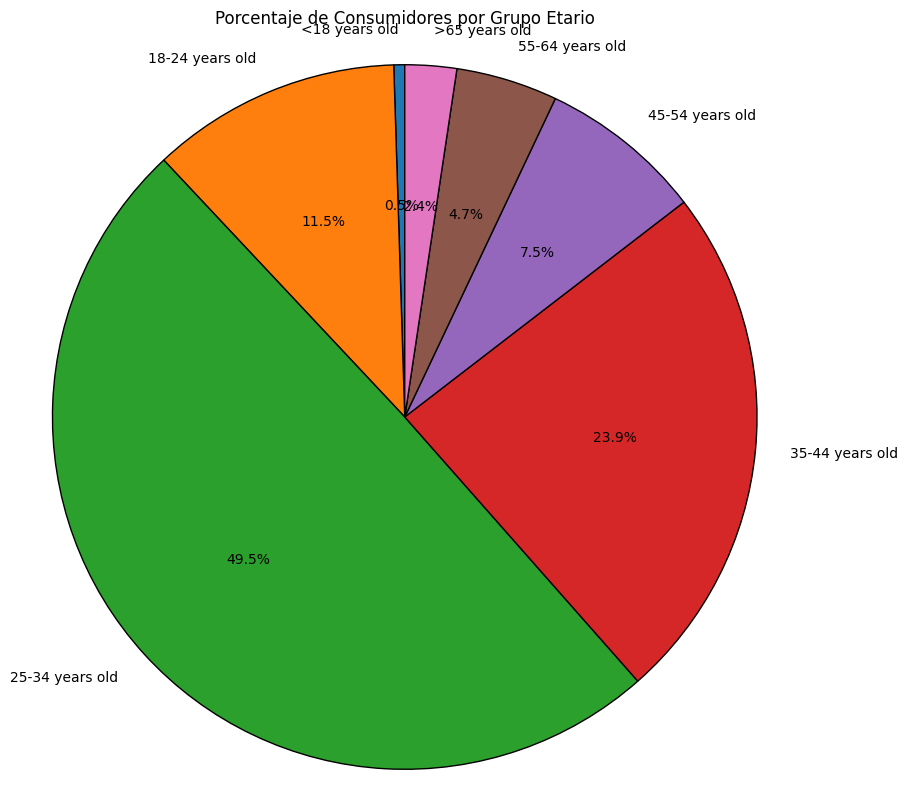

In [12]:
import matplotlib.pyplot as plt

# Calcular el conteo de encuestados por grupo etario
conteo_edades = encuesta['age'].value_counts()

# Reindexar para asegurar un orden lógico en el gráfico (opcional, pero mejora la presentación)
age_order = ['<18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old',
             '>65 years old']
conteo_edades = conteo_edades.reindex(age_order).dropna()

# Generar el Gráfico de Torta
plt.figure(figsize=(10, 10))
plt.pie(conteo_edades,
        labels=conteo_edades.index,
        autopct='%1.1f%%', # Muestra el porcentaje con un decimal
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

# Asegurar que el gráfico sea un círculo
plt.axis('equal')

plt.title('Porcentaje de Consumidores por Grupo Etario')

plt.savefig('consigna_11_grafico_torta_edad.png')

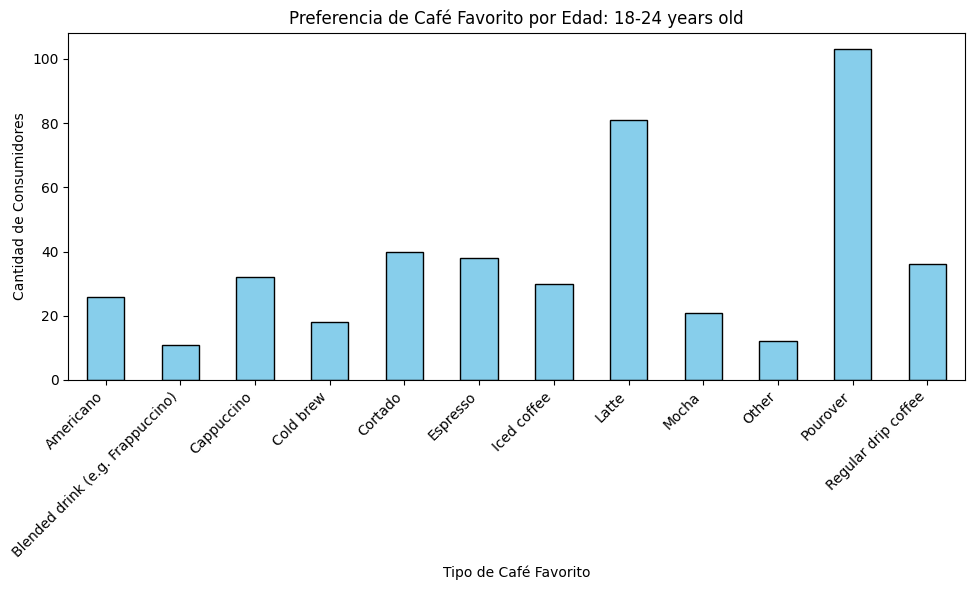

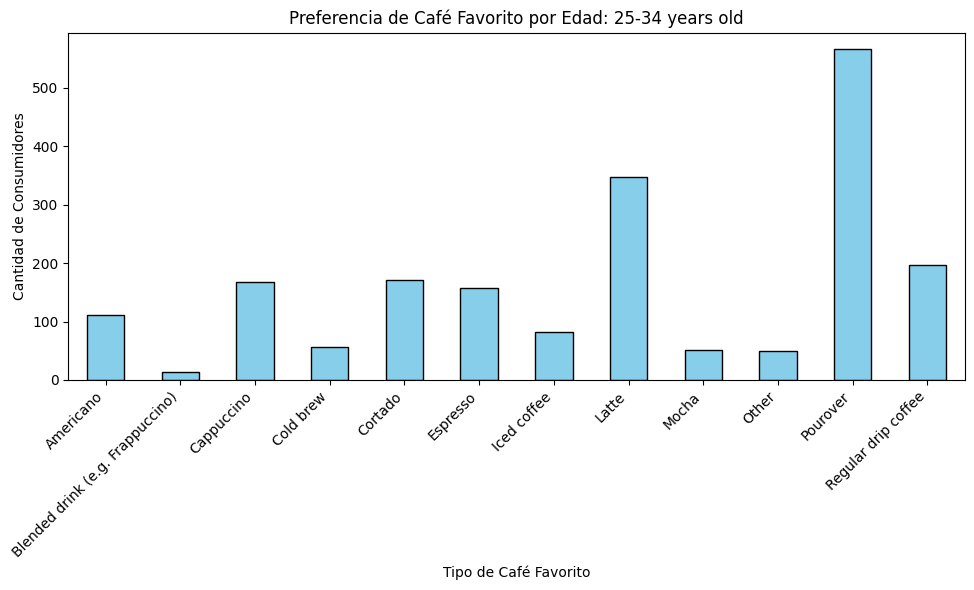

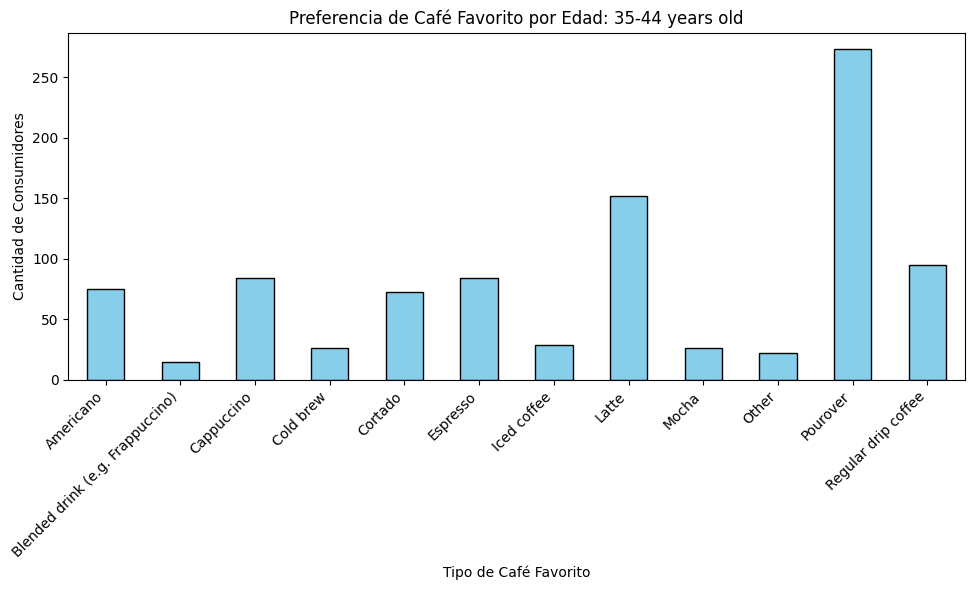

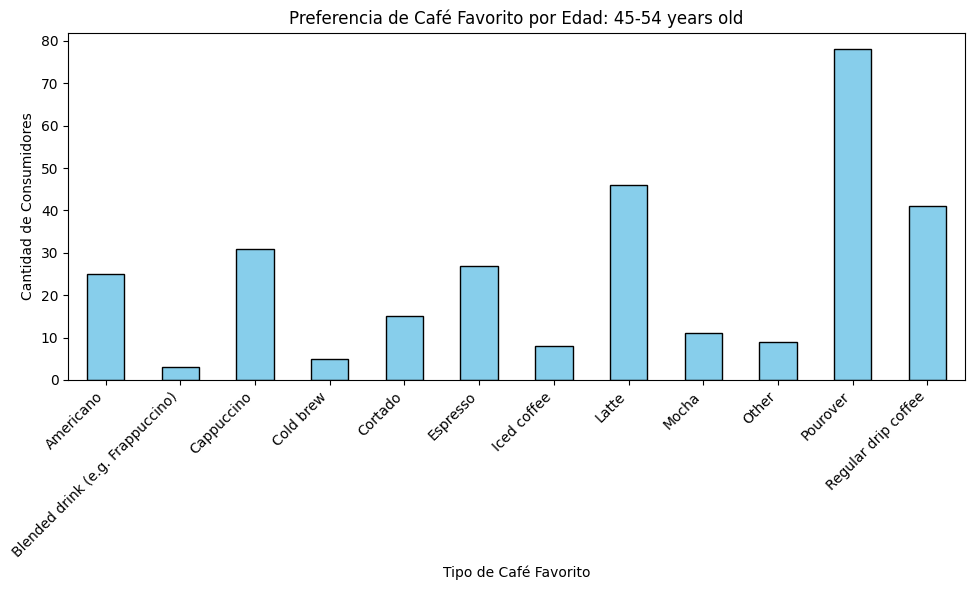

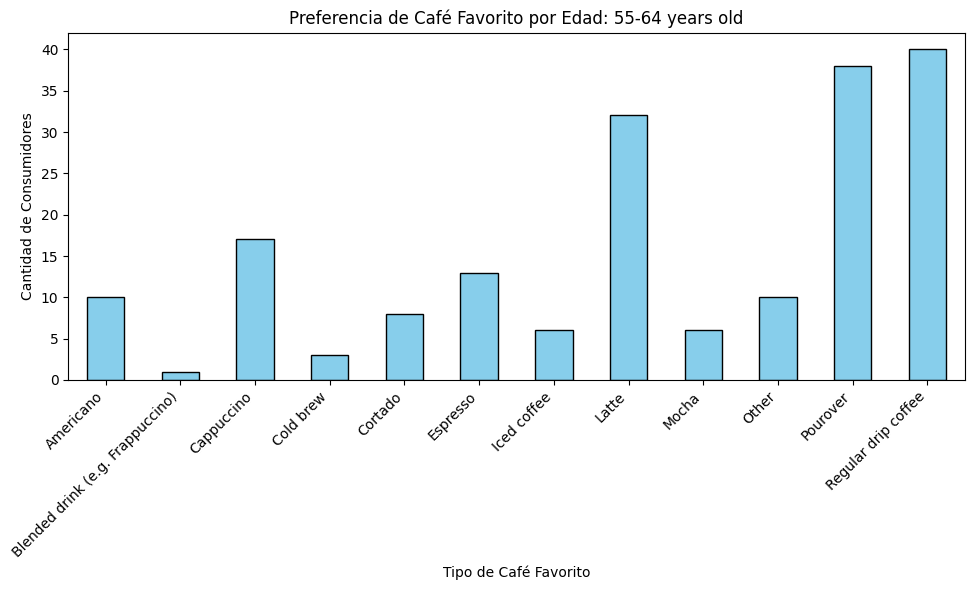

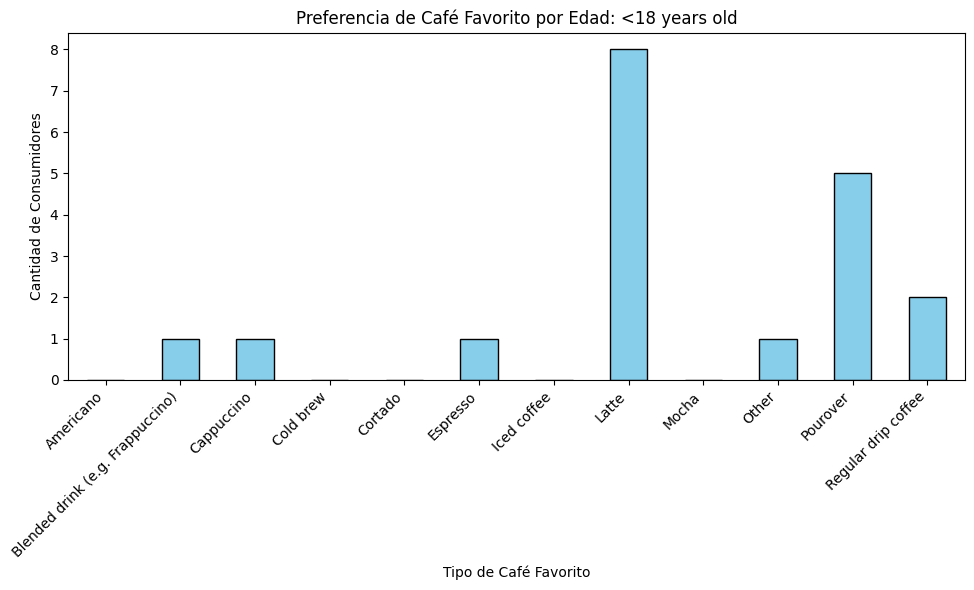

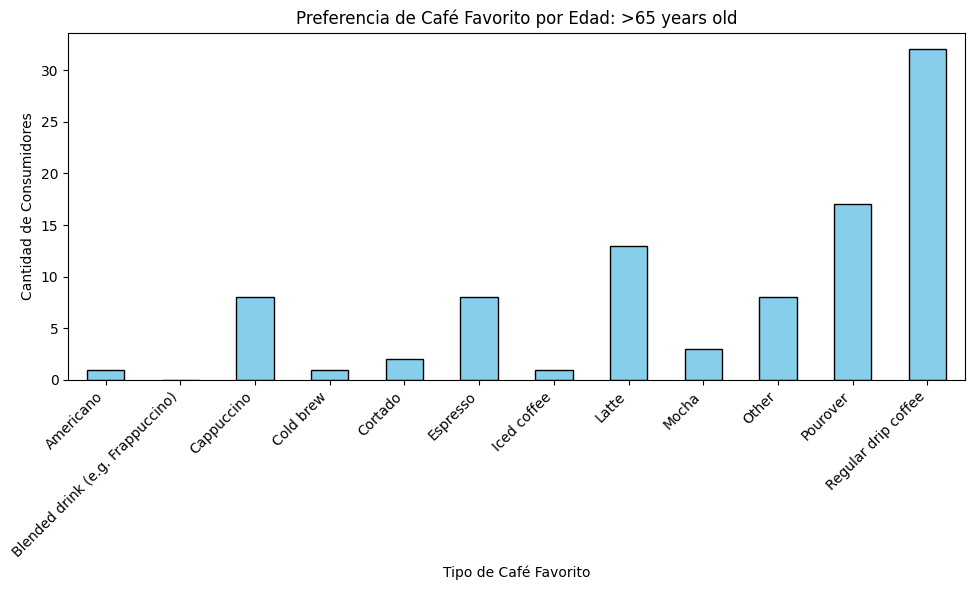

In [16]:
conteo_agrupado = encuesta.groupby('age')['favorite'].value_counts()

# Uso .unstack() para pivotar el índice interno ("favorite") a columnas.
# El resultado es un DataFrame ideal para graficar: Filas=Edades, Columnas=Tipos de Café.
# fill_value=0 reemplaza los NaN que surgen de unstacking (cuando un grupo no eligió un tipo de café)
df_plot = conteo_agrupado.unstack(fill_value=0)

for age_group, counts in df_plot.iterrows():
    # "age_group" es el nombre del grupo de edad (ej. '25-34 years old')
    # "counts" es una Serie con los conteos de café para ese grupo

    if counts.sum() > 0:
        plt.figure(figsize=(10, 6))

        # Generar el gráfico de barras para el grupo actual
        counts.plot.bar(color='skyblue', edgecolor='black')

        plt.title(f'Preferencia de Café Favorito por Edad: {age_group}')
        plt.xlabel('Tipo de Café Favorito')
        plt.ylabel('Cantidad de Consumidores')
        plt.xticks(rotation=45, ha='right') # Rota etiquetas para mejor lectura
        plt.tight_layout()

        # Guarda la imagen con un nombre único basado en el grupo de edad
        file_name = f'grafico_barras_favorito_{age_group.replace(" ", "_").replace("/", "_")}.png'
        plt.savefig(file_name)
        plt.show()
        plt.close()

## **Fase 6: Conclusiones y Recomendaciones Estrategicas**

Basado en los datos, recomendamos orientar la oferta hacia un público joven-adulto con alta educación, priorizando métodos de preparación artesanal, dado el perfil de expertise detectado en la muestra.